## Importação de bibliotecas

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

## Visualização inicial dos dados

In [2]:
df = pd.read_csv('Obesity.csv')

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Tratamento dos dados 

In [4]:
df.isnull().sum().sum()     # Verifying null values in the dataset

0

In [5]:
df.isna().sum().sum()       # verifying NaN values in the dataset

0

In [6]:
df.columns = ['sexo',
              'idade',                              # renaming columns to acess porposes 
              'altura',
              'peso',
              'historico_familiar',
              'f_caloricos',
              'f_vegetais',
              'numero_refeicoes',
              'alimentacao_entre_refeicoes',
              'tabagista',
              'consumo_agua',
              'monitora_calorias',
              'frequencia_exercicio',
              'tempo_tela',
              'consumo_alcool',
              'meio_locomocao',
              'obesidade']   

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sexo                         2111 non-null   object 
 1   idade                        2111 non-null   float64
 2   altura                       2111 non-null   float64
 3   peso                         2111 non-null   float64
 4   historico_familiar           2111 non-null   bool   
 5   f_caloricos                  2111 non-null   bool   
 6   f_vegetais                   2111 non-null   object 
 7   numero_refeicoes             2111 non-null   float64
 8   alimentacao_entre_refeicoes  2111 non-null   int64  
 9   tabagista                    2111 non-null   bool   
 10  consumo_agua                 2111 non-null   object 
 11  monitora_calorias            2111 non-null   bool   
 12  frequencia_exercicio         2111 non-null   object 
 13  tempo_tela        

In [8]:
#função para onde encontrar yes ou no substituir por True ou False  
def yes_no_to_bool(column):
    df[column] = df[column].map({'yes': True, 'no': False})

yes_no_to_bool('historico_familiar')
yes_no_to_bool('f_caloricos')
yes_no_to_bool('tabagista')
yes_no_to_bool('monitora_calorias')

In [9]:
# definindo função para categorizar valores de colunas de tempo em '0', '1', '2', '3' (nenhum, baixo, médio, alto)      

def categorize_time(value):
    if value == 0:
        return '0'
    elif value <  2:
        return '1'
    elif 2 <= value <= 5:
        return '2'
    else:
        return '3'

df['tempo_tela'] = df['tempo_tela'].apply(categorize_time)


In [10]:
# definindo função para categorizar valores de colunas de tempo em '0', '1', '2', '3' (nenhum, baixo, médio, alto)      

def categorize_time(value):
    if value == 0:
        return '0'
    elif value <=  2:
        return '1'
    elif 2 < value <=4:
        return '2'
    else:
        return '3'

df['frequencia_exercicio'] = df['frequencia_exercicio'].apply(categorize_time)

In [11]:
# definindo função para categorizar valores de colunas de tempo em '0', '1', '2', '3' (nenhum, baixo, médio, alto)      

def categorize_time(value):
    if value == 0:
        return '0'
    elif value <=  1:
        return '1'
    elif 1 < value <=2:
        return '2'
    else:
        return '3'

df['consumo_agua'] = df['consumo_agua'].apply(categorize_time)

In [12]:
# definindo função para categorizar valores de colunas de frequencia em '0', '1', '2', '3' (nenhum, baixo, médio, alto)
def categorize_frequency(column):
    df[column] = df[column].apply(
        lambda x: '0' if x == 0 else ('1' if 0 < x <= 2 else ('2' if 2 < x <= 3 else '3'))
    )
categorize_frequency('f_vegetais')


In [13]:
# função para eliminar dados com ruidos decimais.

def remove_decimal_noise(column):
    df[column] = df[column].apply(lambda x: round(x, 0) )
    
remove_decimal_noise('idade')
remove_decimal_noise('numero_refeicoes')

In [14]:
# função para padronizar altura e peso para dois digitos decimais

def standardize_two_decimal(column):
    df[column] = df[column].apply(lambda x: round(x, 2) )
    
standardize_two_decimal('peso')
standardize_two_decimal('altura')

In [15]:
# função para converter altura de metros para centímetros

def meters_to_centimeters(column):
    df[column] = df[column].apply(lambda x: x * 100)

meters_to_centimeters('altura')

In [16]:
#função para padronizar acesso aos dados (maiusculas para minusculas)

def lowercase_columns(column):
    df[column] = df[column].str.lower()
    return df

lowercase_columns('sexo')
lowercase_columns('meio_locomocao')
lowercase_columns('alimentacao_entre_refeicoes')
lowercase_columns('consumo_alcool')
lowercase_columns('obesidade')


,sexo,idade,altura,peso,historico_familiar,f_caloricos,f_vegetais,numero_refeicoes,alimentacao_entre_refeicoes,tabagista,consumo_agua,monitora_calorias,frequencia_exercicio,tempo_tela,consumo_alcool,meio_locomocao,obesidade
0,female,21.0,162.0,64.00,True,False,1,3.0,sometimes,False,2,False,0,1,no,public_transportation,normal_weight
1,female,21.0,152.0,56.00,True,False,2,3.0,sometimes,True,3,True,2,0,sometimes,public_transportation,normal_weight
2,male,23.0,180.0,77.00,True,False,1,3.0,sometimes,False,2,False,1,1,frequently,public_transportation,normal_weight
3,male,27.0,180.0,87.00,False,False,2,3.0,sometimes,False,2,False,1,0,frequently,walking,overweight_level_i
4,male,22.0,178.0,89.80,False,False,1,1.0,sometimes,False,2,False,0,0,sometimes,public_transportation,overweight_level_ii
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,female,21.0,171.0,131.41,True,True,2,3.0,sometimes,False,2,False,1,1,sometimes,public_transportation,obesity_type_iii
2107,female,22.0,175.0,133.74,True,True,2,3.0,sometimes,False,3,False,1,1,sometimes,public_transportation,obesity_type_iii
2108,female,23.0,175.0,133.69,True,True,2,3.0,sometimes,False,3,False,1,1,sometimes,public_transportation,obesity_type_iii
2109,female,24.0,174.0,133.35,True,True,2,3.0,sometimes,False,3,False,1,1,sometimes,public_transportation,obesity_type_iii


In [20]:
# função para padronizar valores de frequencia (no, sometimes, frequently, always)  para (0 , 1, 2, 3)   

def standardize_frequency(column):
    df[column] = df[column].map({'no': 0, 'sometimes': 1, 'frequently': 2, 'always': 3})

standardize_frequency('alimentacao_entre_refeicoes')
standardize_frequency('consumo_alcool')

In [21]:
df.meio_locomocao.unique()

array(['public_transportation', 'walking', 'automobile', 'motorbike',
       'bike'], dtype=object)

In [22]:
df.head()

,sexo,idade,altura,peso,historico_familiar,f_caloricos,f_vegetais,numero_refeicoes,alimentacao_entre_refeicoes,tabagista,consumo_agua,monitora_calorias,frequencia_exercicio,tempo_tela,consumo_alcool,meio_locomocao,obesidade
0,female,21.0,162.0,64.0,True,False,1,3.0,1,False,2,False,0,1,0,public_transportation,normal_weight
1,female,21.0,152.0,56.0,True,False,2,3.0,1,True,3,True,2,0,1,public_transportation,normal_weight
2,male,23.0,180.0,77.0,True,False,1,3.0,1,False,2,False,1,1,2,public_transportation,normal_weight
3,male,27.0,180.0,87.0,False,False,2,3.0,1,False,2,False,1,0,2,walking,overweight_level_i
4,male,22.0,178.0,89.8,False,False,1,1.0,1,False,2,False,0,0,1,public_transportation,overweight_level_ii


# EAD

In [25]:
# estatistica básica para verificar a distribuição dos dados

df.describe()

,idade,altura,peso,numero_refeicoes,alimentacao_entre_refeicoes,consumo_alcool
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,170.162009,86.586035,2.687826,1.140692,0.731407
std,6.357078,9.336840,26.191163,0.809680,0.468543,0.515498
min,14.000000,145.000000,39.000000,1.000000,0.000000,0.000000
25%,20.000000,163.000000,65.470000,3.000000,1.000000,0.000000
50%,23.000000,170.000000,83.000000,3.000000,1.000000,1.000000
75%,26.000000,177.000000,107.430000,3.000000,1.000000,1.000000
max,61.000000,198.000000,173.000000,4.000000,3.000000,3.000000


Text(0.5, 1.0, 'Box Plot - Peso')

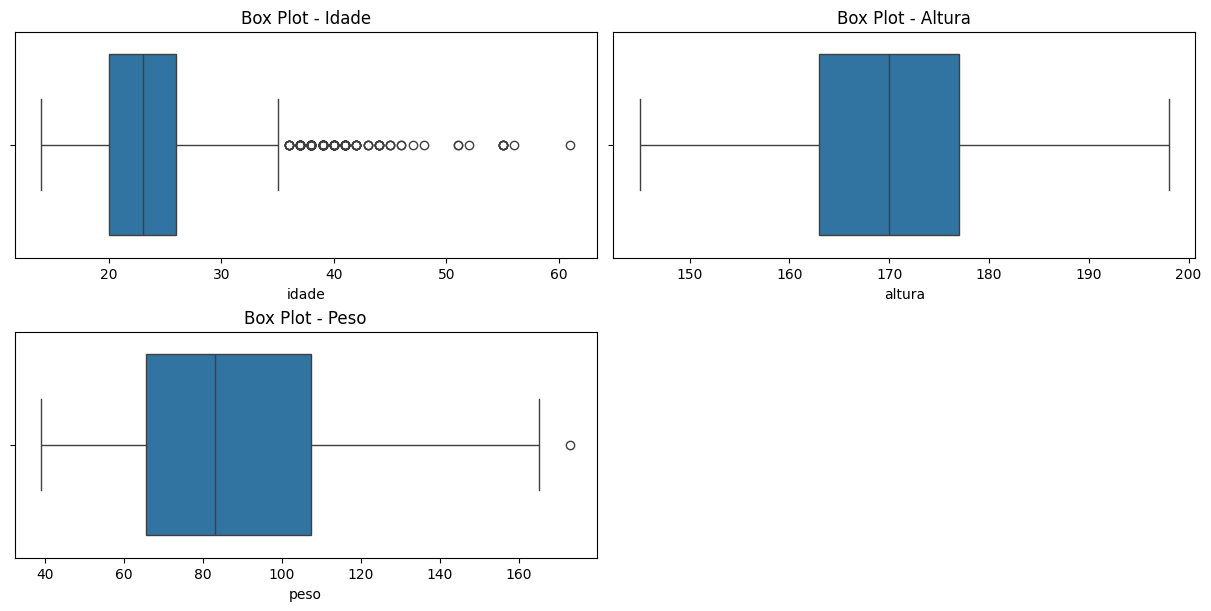

In [36]:
# box plots

plt.figure(figsize=(12, 6), layout='constrained')
plt.subplot(2, 2, 2)

plt.subplot(2, 2, 1)
ax0 = sns.boxplot(x='idade', data = df)
ax0.set_title('Box Plot - Idade')

plt.subplot(2, 2, 2)
ax1 = sns.boxplot(x='altura', data = df)
ax1.set_title('Box Plot - Altura')

plt.subplot(2, 2, 3)
ax2 = sns.boxplot(x='peso', data = df)
ax2.set_title('Box Plot - Peso')




Text(0.5, 1.0, 'Histograma - Sexo')

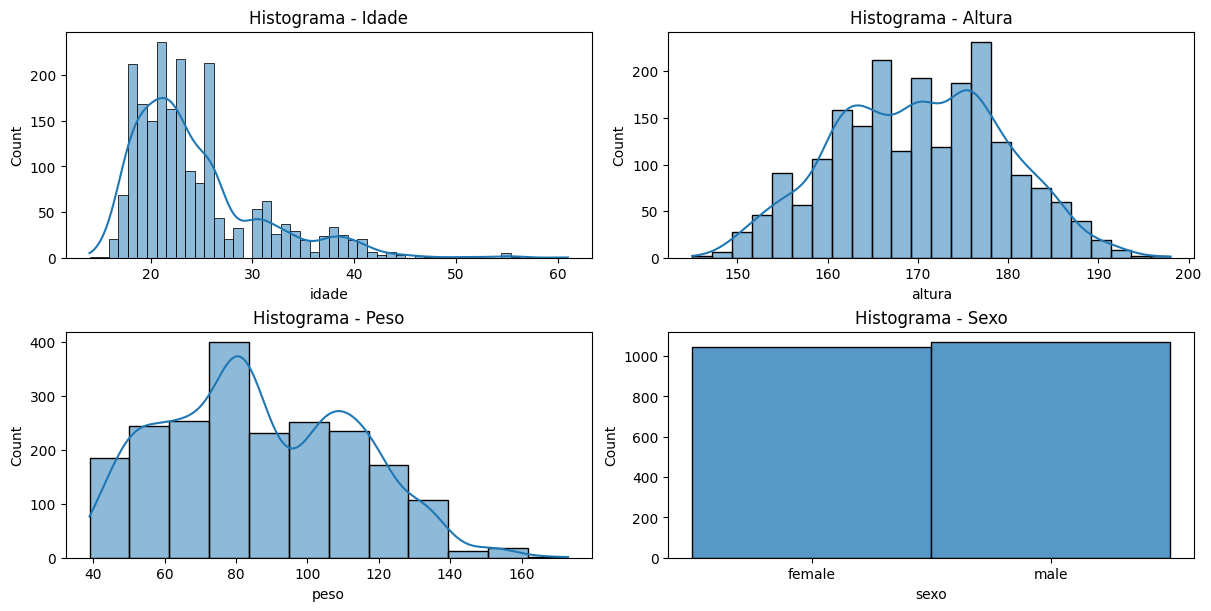

In [51]:
# Histogramas

plt.figure(figsize=(12, 6), layout='constrained')

plt.subplot(2, 2, 1)
ax0 = sns.histplot(x='idade', data=df, bins=50, kde=True)
ax0.set_title('Histograma - Idade') 

plt.subplot(2, 2, 2)
ax1 = sns.histplot(x='altura', data=df, bins=24, kde=True)
ax1.set_title('Histograma - Altura')    

plt.subplot(2, 2, 3)
ax2 = sns.histplot(x='peso', data=df, bins=12, kde=True)
ax2.set_title('Histograma - Peso')  

plt.subplot(2, 2, 4)
ax3 = sns.histplot(x='sexo', data=df, bins=2, kde=False)
ax3.set_title('Histograma - Sexo')

Text(0.5, 1.0, 'Monitora Calorias')

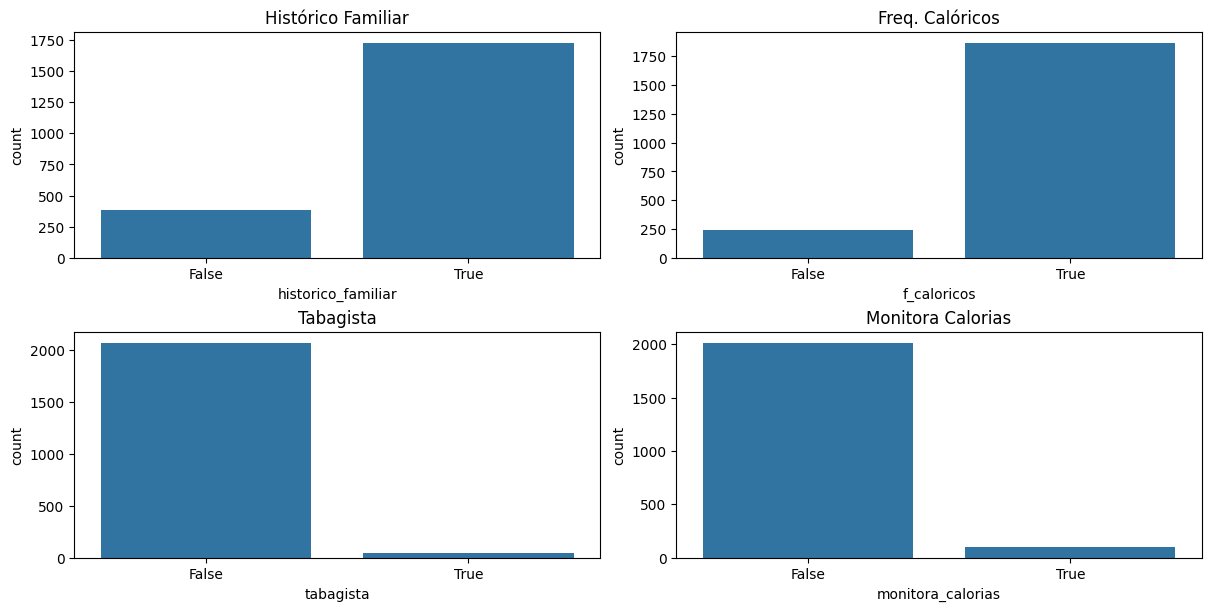

In [53]:
#Histograma

plt.figure(figsize=(12, 6), layout='constrained')

plt.subplot(2, 2, 1)
sns.countplot(x='historico_familiar', data=df)
plt.title('Histórico Familiar')

plt.subplot(2, 2, 2)
sns.countplot(x='f_caloricos', data=df)
plt.title('Freq. Calóricos')

plt.subplot(2, 2, 3)
sns.countplot(x='tabagista', data=df)
plt.title('Tabagista')

plt.subplot(2, 2, 4)
sns.countplot(x='monitora_calorias', data=df)
plt.title('Monitora Calorias')


Text(0.5, 1.0, 'Obesidade')

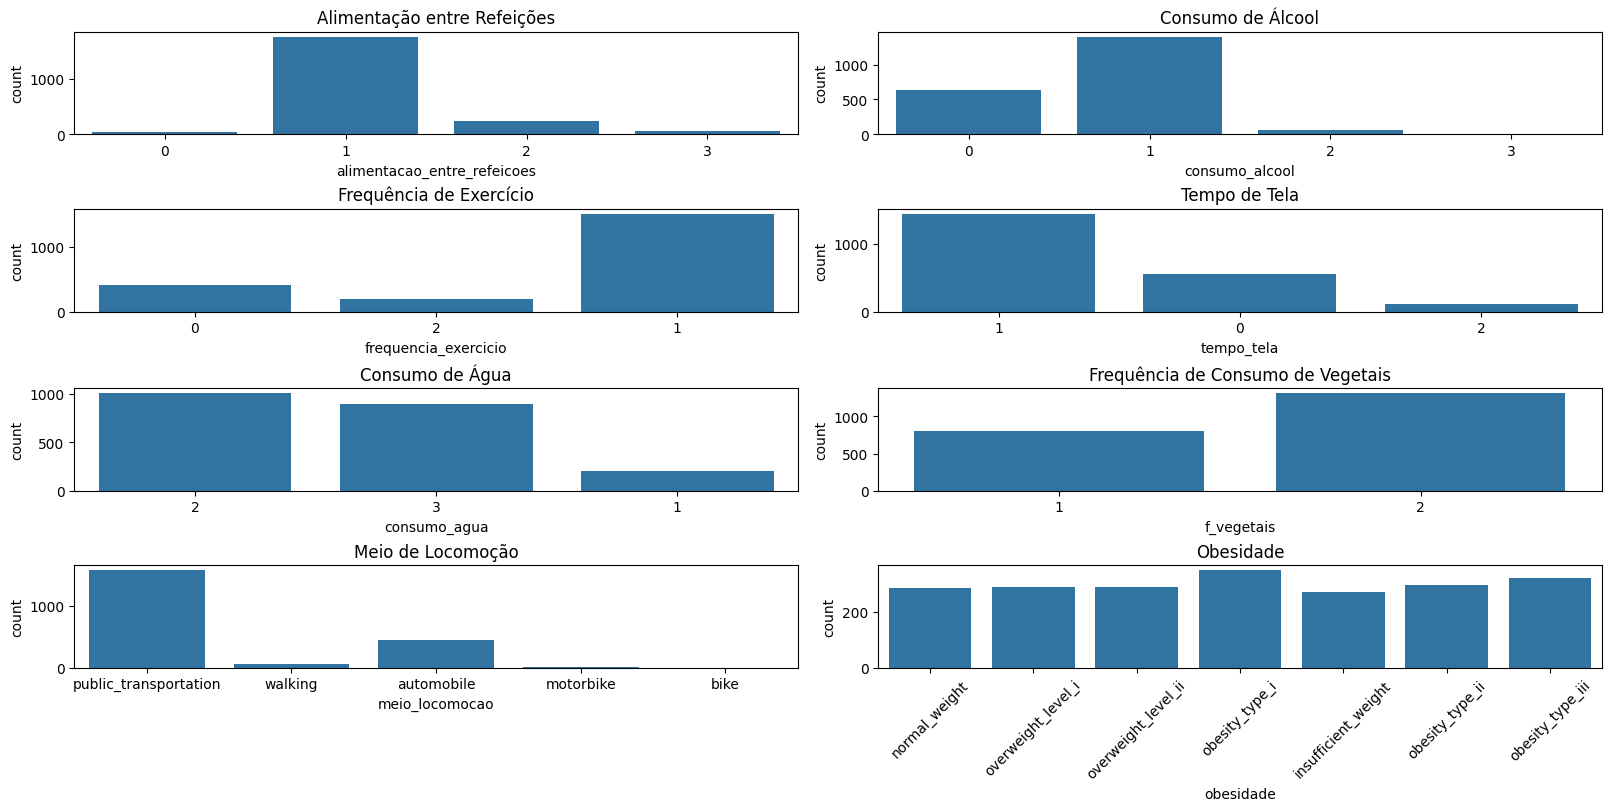

In [57]:
# countplots

from turtle import tilt


plt.figure(figsize=(16, 8), layout='constrained')

plt.subplot(4, 2, 1)
sns.countplot(x='alimentacao_entre_refeicoes', data=df)
plt.title('Alimentação entre Refeições')

plt.subplot(4, 2, 2)
sns.countplot(x='consumo_alcool', data=df)
plt.title('Consumo de Álcool')  

plt.subplot(4, 2, 3)
sns.countplot(x='frequencia_exercicio', data=df)
plt.title('Frequência de Exercício')

plt.subplot(4, 2, 4)
sns.countplot(x='tempo_tela', data=df)  
plt.title('Tempo de Tela')

plt.subplot(4, 2, 5)
sns.countplot(x='consumo_agua', data=df)
plt.title('Consumo de Água')

plt.subplot(4, 2, 6)
sns.countplot(x='f_vegetais', data=df)
plt.title('Frequência de Consumo de Vegetais')  

plt.subplot(4, 2, 7)
sns.countplot(x='meio_locomocao', data=df)  
plt.title('Meio de Locomoção')

plt.subplot(4, 2, 8)
sns.countplot(x='obesidade', data=df)
tilt = plt.xticks(rotation=45)
plt.title('Obesidade')


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sexo                         2111 non-null   object 
 1   idade                        2111 non-null   float64
 2   altura                       2111 non-null   float64
 3   peso                         2111 non-null   float64
 4   historico_familiar           2111 non-null   bool   
 5   f_caloricos                  2111 non-null   bool   
 6   f_vegetais                   2111 non-null   object 
 7   numero_refeicoes             2111 non-null   float64
 8   alimentacao_entre_refeicoes  2111 non-null   int64  
 9   tabagista                    2111 non-null   bool   
 10  consumo_agua                 2111 non-null   object 
 11  monitora_calorias            2111 non-null   bool   
 12  frequencia_exercicio         2111 non-null   object 
 13  tempo_tela        

<Axes: >

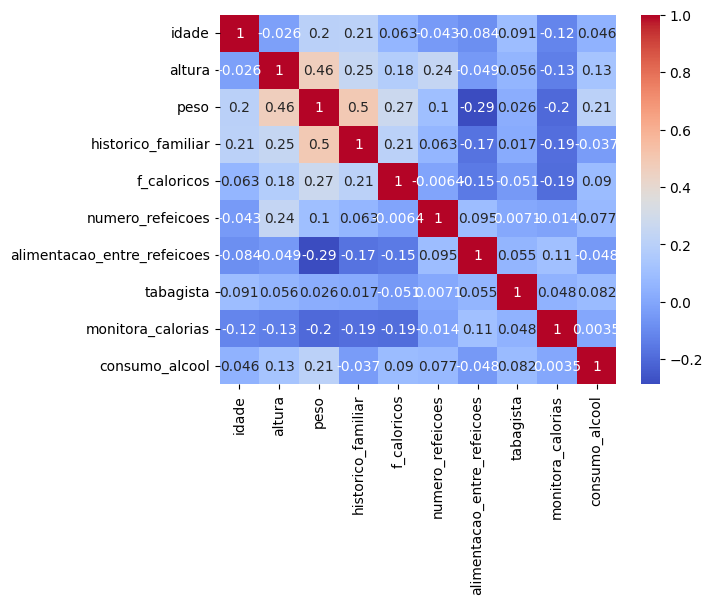

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')



## #sugestao de analise de correlação media ~0,5 entre 
-- peso x altura,
. peso x histórico familiar,
. altura x historico familiar  nao faz sentido no escopo do trabalho


## Sugestao de correlação fraca
. peso x fcaloricos
. peso x alimentação entre refeiçoes (correlaçao negativa)
.

In [65]:
df.groupby(['historico_familiar', 'f_caloricos', 'obesidade'])['sexo'].describe()

count unique     top freq
historico_familiar f_caloricos obesidade                                    
False              False       insufficient_weight    46      2  female   44
                               normal_weight          36      2    male   24
                               obesity_type_i          1      1    male    1
                               obesity_type_ii         1      1  female    1
                               overweight_level_i      7      2    male    4
                               overweight_level_ii     8      2    male    6
                   True        insufficient_weight   100      2  female   85
                               normal_weight          96      2  female   53
                               obesity_type_i          6      2    male    5
                               overweight_level_i     74      2    male   43
                               overweight_level_ii    10      1    male   10
True               False       insufficient_weight     5      2  female    4
                               normal_weight          43      2  female   22
                               obesity_type_i         10      2    male    8
                               obesity_type_ii         6      1    male    6
                               obesity_type_iii        1      1  female    1
                               overweight_level_i     15      2  female    8
                               overweight_level_ii    66      2  female   44
                   True        insufficient_weight   121      2    male   81
                               normal_weight         112      2    male   58
                               obesity_type_i        334      2    male  181
                               obesity_type_ii       290      2    male  289
                               obesity_type_iii      323      2  female  322
                               overweight_level_i    194      2  female  103
                               overweight_level_ii   206      2    male  149